# 최종 미션 — 파이썬 재현 노트북
파일명을 `미션재현_이름.ipynb`로 바꾸고 시작하세요.

## 이 노트북의 사용법 ⚠️ 중요

**코드는 여러분이 직접 씁니다.** 주석으로 "무엇을 해야 하는지"만 안내되어 있습니다.

```python
# [해야 할 일] 결측이 몇 개인지 확인
# [힌트] 표의 정보를 요약해주는 메서드 (교재 2-3장)
# [결과] 어떤 컬럼에 몇 개인지 보여야 함

여기에 코드 작성  ← 이 자리를 채우는 게 여러분의 일
```

### ⚠️ 미션은 스스로 수행합니다

**코드 작성과 분석 판단은 질문 대상이 아닙니다.** 오늘은 심사가 진행되는 날이며, 이 부분이 평가 대상입니다.

| 구분 | 질문 가능 여부 |
|---|---|
| 미션 요구사항·제출 형식이 이해되지 않을 때 | ✅ 질문 가능 |
| 데이터 컬럼의 의미가 이해되지 않을 때 | ✅ 질문 가능 |
| 실행 환경 오류 (파일 업로드, Colab 접속 등) | ✅ 질문 가능 |
| **코드를 어떻게 쓰는지** | ❌ 스스로 해결 |
| **어떤 그래프를 골라야 하는지** | ❌ 스스로 판단 |
| **기준값을 얼마로 정해야 하는지** | ❌ 스스로 판단 |
| **문법 오류·에러 해결** | ❌ 스스로 해결 |

**막혔을 때 찾아볼 자료** (전부 배포되어 있습니다)

| 상황 | 참조 |
|---|---|
| Orange3로는 했는데 코드를 모르겠다 | 교재 **4-9 로제타석** (Orange3 ↔ 파이썬 대응표) |
| 문법이 기억 안 난다 | 교재 **2장** (pandas 4동작) / 어제 실습 노트북 |
| 위젯 조작이 기억 안 난다 | Orange3 매뉴얼 **STEP 1~16** |
| 분석 흐름이 막막하다 | 어제 저녁 관찰 노트북 **Q1~Q6** |

> 💡 **한 번에 완성하려 하지 마세요.** 한 줄 쓰고 실행 → 결과 보고 → 다음 줄. 에러는 정상이며, 에러를 읽고 고치는 것도 평가 대상입니다.

### 📚 출처 메모 (NASA 저장소에서 확인한 내용을 여기에)
```
어떤 실험인가:
제공 기관:
Citation:
원본 형식 → 배포 형식:
```

---
## 준비 — 데이터 불러오기
> 이 셀만 완성되어 있습니다. 나머지는 직접 작성하세요.
> 시작 전: 왼쪽 📁 패널에 `battery_M.csv`와 `battery_NASA.csv`를 모두 드래그 업로드!

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

m = pd.read_csv("/content/battery_M_260722.csv")          # PART 1 · 스냅샷
nasa = pd.read_csv("/content/battery_NASA_260722.csv")    # PART 2 · 시계열

print("M   :", m.shape, "  한 행 = 셀 하나")
print("NASA:", nasa.shape, "  한 행 = 셀 하나의 한 사이클")

M   : (30, 9)   한 행 = 셀 하나
NASA: (636, 11)   한 행 = 셀 하나의 한 사이클


---
# PART 1 — M데이터 (스냅샷)
## 필수 재현 ① · 데이터 확인
> Orange3의 **Column Statistics**로 본 것을 코드로 다시 확인합니다.

In [25]:
# ─────────────────────────────────────────────
# [해야 할 일] 데이터의 앞부분을 눈으로 확인
# [힌트] 표의 첫 몇 줄만 보여주는 메서드
# ─────────────────────────────────────────────
m.head()

,cell_id,cycle_count,initial_capacity,current_capacity,soh,internal_resistance,avg_temp,charge_time,batch_no
0,M01,725,2808.1,2583.5,92.0,32.6,30.1,93,2
1,M02,776,2782.8,2379.3,85.5,38.4,32.5,123,1
2,M03,243,2799.5,2617.5,93.5,39.5,27.1,109,2
3,M04,597,2811.9,2266.4,80.6,42.9,33.9,113,1
4,M05,210,2751.7,2724.2,99.0,28.9,27.2,97,3


In [26]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 컬럼의 타입과 결측(Non-Null) 개수 확인
# [힌트] "출석부 훑기" — 교재 2-3장의 세 버튼 중 두 번째
# [결과] 어떤 컬럼에 결측이 몇 개인지 알 수 있어야 함
# ─────────────────────────────────────────────
m.info()

# ✏️ 확인한 내용 (발표 3·4장 재료):
#    결측 컬럼:     current_capacity          개수: 3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              30 non-null     object 
 1   cycle_count          30 non-null     int64  
 2   initial_capacity     30 non-null     float64
 3   current_capacity     27 non-null     float64
 4   soh                  30 non-null     float64
 5   internal_resistance  30 non-null     float64
 6   avg_temp             30 non-null     float64
 7   charge_time          30 non-null     int64  
 8   batch_no             30 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 2.2+ KB


In [27]:
# ─────────────────────────────────────────────
# [해야 할 일] 수치 컬럼의 요약 통계로 이상한 값 찾기
# [힌트] 세 버튼 중 세 번째. min/max를 유심히 볼 것
# [결과] 물리적으로 불가능한 값이 눈에 띄어야 함
# ─────────────────────────────────────────────
m.describe()

# ✏️ 이상치: 컬럼     soh        값      121       왜 불가능한가: soh = current_capacity / initial_capacity *100 이므로 100을 넘을수 없다.


,cycle_count,initial_capacity,current_capacity,soh,internal_resistance,avg_temp,charge_time,batch_no
count,30.000000,30.000000,27.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,555.266667,2797.073333,2587.214815,93.160000,33.113333,30.850000,100.066667,2.133333
std,221.722867,23.290947,148.545827,7.603747,5.818682,3.680494,10.891102,0.860366
min,152.000000,2751.700000,2266.400000,80.600000,24.000000,23.500000,75.000000,1.000000
25%,372.250000,2782.975000,2478.800000,88.125000,28.550000,28.300000,92.250000,1.000000
50%,593.500000,2798.800000,2592.900000,93.000000,32.250000,31.400000,100.000000,2.000000
75%,716.000000,2808.325000,2712.800000,97.900000,38.550000,33.200000,109.000000,3.000000
max,886.000000,2856.200000,2777.800000,121.000000,42.900000,36.300000,123.000000,3.000000


In [28]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 제외한 데이터를 m_clean 이라는 이름으로 만들기
# [힌트] 조건을 걸어 골라내기 = 마스킹 (교재 1-5, 2-5장)
#        SOH는 100%를 넘을 수 없다
# [결과] print로 제거 전/후 행 수를 비교해 보세요
# ─────────────────────────────────────────────
m_clean = m[m['soh'] <= 100]

print('제거 전 데이터 수', len(m))
print('제거 후 데이터 수', len(m_clean))



제거 전 데이터 수 30
제거 후 데이터 수 29


## 필수 재현 ② · 최종 판정
> Orange3의 **Select Rows**로 한 선별을 코드로 재현합니다. **두 결과가 같아야 정상입니다.**

In [29]:
# ─────────────────────────────────────────────
# [해야 할 일] 내가 Orange3에서 정한 기준을 조건으로 옮겨 최종 셀 선별
# [힌트] 조건이 2개 이상이면 각각 괄호로 감싸고 & 로 연결
#        df[(조건1) & (조건2)]  ← 괄호 빠뜨리면 에러 (오늘의 1등 에러)
# [결과] 선별된 셀 수를 출력하고, cell_id와 soh를 확인
# ─────────────────────────────────────────────
final = m_clean[(m_clean['current_capacity'] >= 2600) & ( m_clean['current_capacity'] <= 2750) & ( m_clean['internal_resistance'] < 35)]
print("파이썬 선별 결과:", len(final), "개")
final[['cell_id', 'current_capacity', 'internal_resistance']]
#  2600 <= current_capacity <= 2750  &  internal_resistance <= 35



파이썬 선별 결과: 7 개


,cell_id,current_capacity,internal_resistance
4,M05,2724.2,28.9
6,M07,2715.1,31.2
8,M09,2682.6,26.4
12,M13,2686.6,26.5
13,M14,2635.6,30.0
16,M17,2616.6,31.9
24,M25,2710.5,29.6


In [30]:
# ─────────────────────────────────────────────
# [해야 할 일] Orange3 결과와 일치하는지 대조
# ─────────────────────────────────────────────
# ✏️ Orange3 Select Rows의 Data Out 셀 수:       7 개
# ✏️ 파이썬 len(final):                          7 개
# ✏️ 일치? 예
#    → 아니오라면: 부등호 방향(>= vs >), 기준값, 조건 개수를 하나씩 대조해 보세요


---
# 관문 ① · 기준 민감도 ★변별
### "그 기준, 흔들리면 결과가 얼마나 달라지나요?"

기준값 하나로 판정하고 끝내면 평범합니다. **기준이 얼마나 예민한지 수치로** 보여주세요.

In [31]:
# ─────────────────────────────────────────────
# [해야 할 일] 내 기준값을 -3 / 그대로 / +3 으로 바꿔가며
#              각각 몇 개가 통과하는지 표처럼 출력
#
# [생각해볼 것] 같은 코드를 값만 바꿔 3번 쓰는 것보다,
#               값 목록을 만들어 반복시키는 게 낫지 않을까?
#               (어제 배운 for문 — 리스트를 하나씩 꺼내 쓰기)
#
# [결과 예시]
#   soh >= 82: 통과 26개 / 탈락 3개
#   soh >= 85: 통과 24개 / 탈락 5개
#   soh >= 88: 통과 22개 / 탈락 7개
# ─────────────────────────────────────────────
# 기준에서 +- 2% -> 2548 <= current_capacity <= 2805  &  internal_resistance <= 35.7 (+2%)
#                   2652 <= current_capacity <= 2695  &  internal_resistance <= 34.3 (-2%)
final_relaxed_2pct = m_clean[(m_clean['current_capacity'] >= 2548) & (m_clean['current_capacity'] <= 2805) & (m_clean['internal_resistance'] < 35.7)]
print("기준 대비 2% 완화 선별 결과:", len(final_relaxed_2pct), "개")
display(final_relaxed_2pct[['cell_id', 'current_capacity', 'internal_resistance']])

final_strict_2pct = m_clean[(m_clean['current_capacity'] >= 2652) & (m_clean['current_capacity'] <= 2695) & (m_clean['internal_resistance'] < 34.3)]
print("기준 대비 2% 규제 선별 결과:", len(final_strict_2pct), "개")
display(final_strict_2pct[['cell_id', 'current_capacity', 'internal_resistance']])




# ✏️ 발표 7장 문장: "기준을 3%p 낮추면 __개가 더 통과합니다.
#                    그만큼 예민한 경계이므로 __를 근거로 __로 정했습니다"


기준 대비 2% 완화 선별 결과: 15 개


,cell_id,current_capacity,internal_resistance
0,M01,2583.5,32.6
4,M05,2724.2,28.9
6,M07,2715.1,31.2
7,M08,2766.3,25.1
8,M09,2682.6,26.4
12,M13,2686.6,26.5
13,M14,2635.6,30.0
14,M15,2773.0,24.8
15,M16,2772.3,24.0
16,M17,2616.6,31.9


기준 대비 2% 규제 선별 결과: 2 개


,cell_id,current_capacity,internal_resistance
8,M09,2682.6,26.4
12,M13,2686.6,26.5


In [32]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 내 기준 경계에 아슬아슬하게 걸린 셀 찾기
# [힌트] 기준값 ±2 범위에 있는 셀만 골라내면 됩니다 (조건 2개)
# [왜?] "이 셀은 왜 탈락시켰나요?" 질문에 사례로 답할 수 있습니다
# ─────────────────────────────────────────────



---
# 관문 ② · 결측의 영향 ★변별
### "빈칸을 채운 게 답을 바꾸지 않았나요?"

결측을 평균으로 채우고 넘어가면 놓치는 게 있습니다.

In [33]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 결측이 있던 셀들이 어떤 값을 가졌는지 확인
# [힌트] 결측 여부를 판단하는 메서드가 있습니다 (NaN인가?)
#        그 결과를 마스킹 조건으로 쓰면 결측 행만 골라집니다
# [보고 싶은 것] 그 셀들의 cell_id, soh, internal_resistance
# ─────────────────────────────────────────────
nan_cells = m_clean[m_clean['current_capacity'].isna()]
display(nan_cells[['cell_id', 'soh', 'internal_resistance']])

# ✏️ 결측 셀들의 SOH는 합격 경계 근처인가, 확실한 불합격인가?
# current_capacity의 값을 없지만 앞서 세운 기준인 internal_resistance < 35 를 충족하지 못하였으므로 결측 셀들은 확실한 불합격이다.

,cell_id,soh,internal_resistance
5,M06,87.3,42.8
17,M18,85.1,41.5
26,M27,94.4,35.9


In [34]:
# ─────────────────────────────────────────────
# [해야 할 일 2] 결측을 두 가지 방식으로 처리하고 최종 판정을 비교
#   ⓐ 평균으로 채우기  → 내 기준 적용 → 몇 개 통과?
#   ⓑ 해당 행 제외하기 → 내 기준 적용 → 몇 개 통과?
#
# [힌트] 빈칸 채우기 / 빈칸 있는 행 버리기에 해당하는 메서드가 각각 있습니다
#        (교재 4-9 로제타석의 '결측 채우기' 행 참고)
# [결과] 두 방식의 최종 셀 수를 나란히 출력
# ─────────────────────────────────────────────
m_filled = m_clean.copy()
mean_cap = m_filled['current_capacity'].mean()
m_filled['current_capacity'] = m_filled['current_capacity'].fillna(mean_cap)

m_dropped = m_clean.dropna(subset=['current_capacity'])

final_a = m_filled[(m_filled['current_capacity'] >= 2600) & (m_filled['current_capacity'] <= 2750) & (m_filled['internal_resistance'] < 35)]
final_b = m_dropped[(m_dropped['current_capacity'] >= 2600) & (m_dropped['current_capacity'] <= 2750) & (m_dropped['internal_resistance'] < 35)]

print("a 결측치를 평균으로 채운 경우 최종 통과:", len(final_a), "개")
print("b 결측치를 버린 경우 최종 통과:", len(final_a), "개")

# ✏️ 판정이 달라졌는가? 나는 어느 쪽을 택했고 왜인가:
# 결측치를 포함 하든 안하든 앞서 세운 기준에 이미 불합격이기 때문에 미리 제외되었기 때문에 최종 통과된 것들에는 영향이 없다. 결과가 같은데 굳이 가짜 데이터를 넣을 필요는 없다 생각해 제거하는 방향으로 할 것.

a 결측치를 평균으로 채운 경우 최종 통과: 7 개
b 결측치를 버린 경우 최종 통과: 7 개


---
# 관문 ③ · 함정 회피 ★변별
### "상관 1위가 정말 원인인가요?"

이 데이터에는 **의도적으로 심어둔 함정**이 있습니다. 순위표만 보면 걸립니다.

In [35]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 "제거하기 전(m)"과 "제거한 후(m_clean)"의
#              SOH 상관 순위를 각각 구해서 비교
#
# [힌트] 상관은 corr() — 단, cell_id는 글자라 계산에서 빼야 합니다
#        특정 열을 빼는 방법: drop(columns=[...])
#        SOH 기준 순위만 보려면 결과에서 'soh' 열을 뽑고 정렬
# [결과] 두 순위표를 나란히 출력해 어떤 변수의 순위가 크게 움직였는지 확인
# ─────────────────────────────────────────────
corr_before = m.drop(columns=['cell_id']).corr()['soh'].sort_values(ascending=False)
corr_after = m_clean.drop(columns=['cell_id']).corr()['soh'].sort_values(ascending=False)

print("--- [제거 전] SOH 상관관계 순위 ---")
print(corr_before)
print("\n--- [제거 후] SOH 상관관계 순위 ---")
print(corr_after)



--- [제거 전] SOH 상관관계 순위 ---
soh                    1.000000
current_capacity       0.679110
batch_no               0.411979
initial_capacity       0.027397
cycle_count           -0.210082
avg_temp              -0.216368
charge_time           -0.259754
internal_resistance   -0.446378
Name: soh, dtype: float64

--- [제거 후] SOH 상관관계 순위 ---
soh                    1.000000
current_capacity       0.991175
batch_no               0.598602
cycle_count           -0.325065
avg_temp              -0.336624
initial_capacity      -0.341384
charge_time           -0.391908
internal_resistance   -0.842087
Name: soh, dtype: float64


<Axes: title={'center': 'Trap Check: Batch No vs SOH'}, xlabel='batch_no', ylabel='soh'>

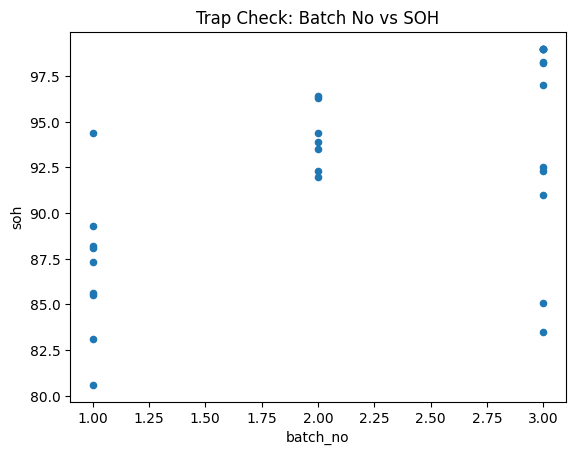

In [36]:
# ─────────────────────────────────────────────
# [해야 할 일] 의심스러운 변수를 산점도로 다시 확인
# [힌트] 산점도는 plot.scatter(x=..., y=...)
# [따져볼 것] 이 변수가 배터리를 늙게 할 "물리적 이유"가 있는가?
#             (예: 생산 배치 번호가 커지면 배터리가 빨리 늙는다? 말이 되는가?)
# ─────────────────────────────────────────────

m_clean.plot.scatter(x='batch_no', y='soh', title="Trap Check: Batch No vs SOH")
# ✏️ 상관 1위 변수:              물리적으로 타당한가?
# ✏️ 함정으로 의심되는 변수:              배제 이유:


---
# PART 2 — NASA 데이터 (시계열)
## 2단계 · 데이터 확인

In [37]:
# ─────────────────────────────────────────────
# [해야 할 일] NASA 데이터의 구조 파악 — 앞부분 + 결측 확인
# [주목] 결측이 있다면 어느 컬럼에, 몇 개나?
# ─────────────────────────────────────────────
display(nasa.head())
print(nasa.isnull().sum())



,cell_id,cycle_count,ambient_temp,capacity,soh,internal_resistance,avg_temp,max_temp,discharge_time,min_voltage,is_eol
0,B0005,1,24,1.8565,92.8,NaN,32.6,39.0,61.5,2.612,0
1,B0005,2,24,1.8463,92.3,NaN,32.7,39.0,61.2,2.587,0
2,B0005,3,24,1.8353,91.8,NaN,32.6,38.8,60.9,2.652,0
3,B0005,4,24,1.8353,91.8,NaN,32.5,38.8,60.5,2.593,0
4,B0005,5,24,1.8346,91.7,NaN,32.4,38.7,60.5,2.547,0


cell_id                 0
cycle_count             0
ambient_temp            0
capacity                0
soh                     0
internal_resistance    57
avg_temp                0
max_temp                0
discharge_time          0
min_voltage             0
is_eol                  0
dtype: int64


In [38]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 셀마다 사이클 수가 다른지 확인
# [힌트] 셀별로 묶어서(groupby) 각 그룹의 최대 사이클을 보면 됩니다
# [왜?] 셀마다 관측 길이가 다르면 비교할 때 주의해야 합니다 (발표 '한계' 재료)
# ─────────────────────────────────────────────
max_cycles_per_cell = nasa.groupby('cell_id')['cycle_count'].max()
print("▶ 셀별 최대 사이클 수:\n", max_cycles_per_cell)
print("\n" + "="*50 + "\n")

# ─────────────────────────────────────────────
# [해야 할 일 2 · 관문② 심화] 결측이 어디에 있는지 확인 ★
# [힌트] 결측인 행만 골라낸 뒤, 셀별·사이클별로 어디에 몰려 있는지 보세요
#        (groupby로 묶어 min/max 사이클을 보면 구간이 드러납니다)
# [따져볼 것] 결측이 무작위인가, 특정 구간에 몰려 있는가?
#             몰려 있다면 평균으로 채우는 게 왜 위험한가?
# ─────────────────────────────────────────────
missing_data = nasa[nasa['internal_resistance'].isnull()]

missing_summary = missing_data.groupby('cell_id')['cycle_count'].agg(['min', 'max', 'count'])
print("▶ 결측치가 발생한 사이클 구간:\n", missing_summary)

# ✏️ 결측 구간:                     평균 대체가 위험한 이유:


▶ 셀별 최대 사이클 수:
 cell_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: cycle_count, dtype: int64


▶ 결측치가 발생한 사이클 구간:
          min  max  count
cell_id                 
B0005      1   19     19
B0006      1   19     19
B0007      1   19     19


## 3단계 · 열화 곡선 그리기 ★ 오늘의 핵심 그래프
> Orange3에서는 산점도로 봤지만, 파이썬에서는 **진짜 선 그래프**를 그릴 수 있습니다.

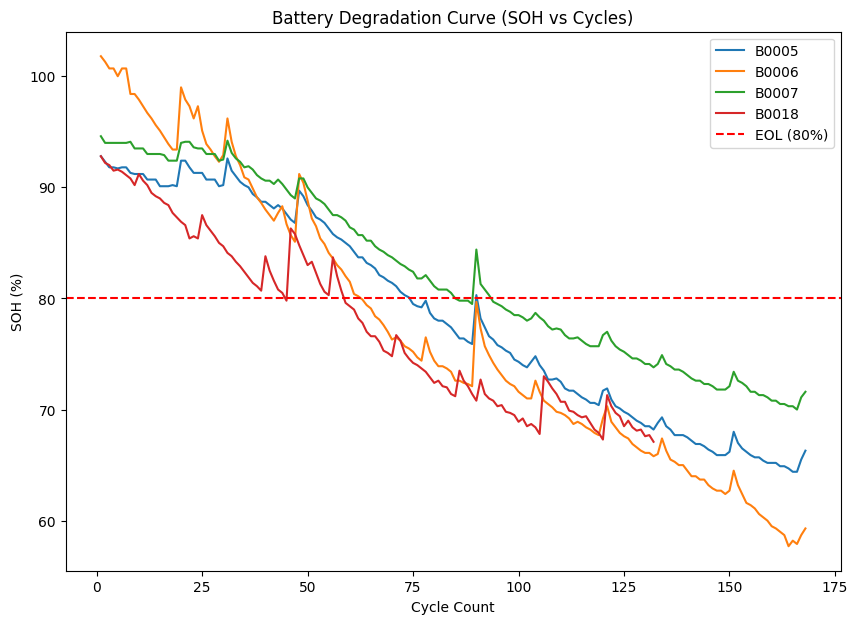

In [39]:
# ─────────────────────────────────────────────
# [해야 할 일] 셀마다 선을 하나씩 그려서, 사이클에 따른 SOH 변화 표시
#
# [설계 힌트]
#   1) 셀별로 데이터를 나눠야 한다 → groupby로 묶으면 (이름, 데이터) 쌍이 나옵니다
#   2) 각 셀마다 선을 하나씩 → plt.plot(x축값, y축값, label=셀이름)
#   3) EOL 기준선 80%를 가로선으로 → plt.axhline(80, color='red', linestyle='--')
#   4) 범례·축 이름 → plt.legend(), plt.xlabel(), plt.ylabel()
#   5) 마지막에 plt.show()
#
# [결과] 왼쪽 위에서 오른쪽 아래로 흘러내리는 곡선 4개 + 빨간 기준선
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for cell_name, cell_data in nasa.groupby('cell_id'):
    plt.plot(cell_data['cycle_count'], cell_data['soh'], label=cell_name)

plt.axhline(80, color='red', linestyle='--', label='EOL (80%)')

plt.legend()
plt.xlabel('Cycle Count')
plt.ylabel('SOH (%)')
plt.title('Battery Degradation Curve (SOH vs Cycles)')

plt.show()

# ✏️ 이 그림에서 알게 된 것 한 문장 (발표 8장): 사이클이 늘어날수록 4개 셀 모두 SOH값이 떨어지는 우하향 그래프를 그림. EOL이 80%인 지점을 통과하는 지점도 4개 셀 모두 시점이 다르EK. 초기를 보면 처음 사이클을 돌릴때 B0006이 가장 높았지만 가장 늦게 한계 수명에 다다른것은 아니며 B0018과 B0005이 초기에 가장 낮은 용량을 가졌음에도 B0018이 가장 빨리 한게 수명에 다다른걸 보면 영향이


In [40]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 셀이 몇 번째 사이클에 EOL(SOH 80% 미만)에 도달했는지
# [힌트] EOL 여부를 나타내는 컬럼이 이미 있습니다 (is_eol)
#        그 값이 1인 행만 고른 뒤, 셀별로 묶어서 가장 작은 사이클을 찾으면 됩니다
# [결과] 셀 4개의 EOL 도달 사이클
# ─────────────────────────────────────────────
eol_data = nasa[nasa['is_eol'] == 1]

eol_cycles = eol_data.groupby('cell_id')['cycle_count'].min()

print("▼ 각 셀이 EOL(SOH 80% 미만)에 도달한 최초 사이클 ▼")
print(eol_cycles)

# ✏️ 가장 빨리 죽은 셀:    18      가장 오래 버틴 셀:    7      차이:     40 사이클


▼ 각 셀이 EOL(SOH 80% 미만)에 도달한 최초 사이클 ▼
cell_id
B0005    75
B0006    63
B0007    86
B0018    45
Name: cycle_count, dtype: int64


---
# 관문 ④ · 교차 검증 ★변별
### "PART 1의 발견이 PART 2에서도 성립하나요?"

두 데이터를 따로 분석하고 끝내면 절반입니다. **연결**하세요.

In [41]:
# ─────────────────────────────────────────────
# [해야 할 일] PART 1에서 찾은 열화 신호(변수)가
#              NASA 데이터에서도 같은 방향인지 상관으로 확인
#
# [힌트] 두 데이터 각각에서 해당 변수와 soh의 상관계수를 구해 나란히 출력
# [따져볼 것] 방향(+/-)은 같은가? 강도는? 왜 차이가 날까?
# ─────────────────────────────────────────────
corr_m = -0.842087
corr_nasa = nasa['internal_resistance'].corr(nasa['soh'])

print("▶ M데이터 상관:", corr_m)
print("▶ NASA 상관:", corr_nasa)

# ✏️ M데이터 상관: -0.842087         NASA 상관: -0.712684
# ✏️ 나의 해석 (발표 9장): 둘 다 음의 상관관계를 가지므로 내부 저항이 커질수록 SOH가 감소한다.


▶ M데이터 상관: -0.842087
▶ NASA 상관: -0.7126842229476168


In [42]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별로 나눠서 본 상관 vs 전체를 한 덩어리로 본 상관 ★
# [힌트] groupby로 셀을 나눈 뒤, 각 그룹에서 저항-SOH 상관을 구해 비교
# [따져볼 것] 셀마다 값이 크게 다른가? 전체 상관과 차이가 나는가?
#             다르다면 "평균의 함정"일 수 있습니다
# ─────────────────────────────────────────────
print("▶ 전체 한 덩어리로 본 상관계수:", nasa['internal_resistance'].corr(nasa['soh']))
nasa_clean = nasa.dropna(subset=['internal_resistance', 'soh'])
corr_per_cell = nasa_clean.groupby('cell_id').apply(lambda x: x['internal_resistance'].corr(x['soh']))
print("\n▶ 셀별로 나눠서 본 상관계수:\n", corr_per_cell)

# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별 열화 속도(기울기) 비교
# [힌트] (첫 SOH - 마지막 SOH) / 사이클 수, 또는 numpy polyfit으로 직선 맞추기
# ─────────────────────────────────────────────
def calculate_slope(df):
    first_soh = df['soh'].iloc[0]
    last_soh = df['soh'].iloc[-1]
    total_cycles = df['cycle_count'].max()
    return (last_soh - first_soh) / total_cycles
slopes = nasa.groupby('cell_id').apply(calculate_slope)

print("▶ 셀별 열화 속도 (1사이클당 SOH 감소량 %):\n", slopes)



▶ 전체 한 덩어리로 본 상관계수: -0.7126842229476168

▶ 셀별로 나눠서 본 상관계수:
 cell_id
B0005   -0.929141
B0006   -0.982485
B0007   -0.961474
B0018   -0.558846
dtype: float64
▶ 셀별 열화 속도 (1사이클당 SOH 감소량 %):
 cell_id
B0005   -0.157738
B0006   -0.252976
B0007   -0.136905
B0018   -0.194697
dtype: float64


/tmp/ipykernel_2613/1681675048.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_per_cell = nasa_clean.groupby('cell_id').apply(lambda x: x['internal_resistance'].corr(x['soh']))
/tmp/ipykernel_2613/1681675048.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = nasa.groupby('cell_id').apply(calculate_slope)


---
# 4단계 · 결론·한계 메모
발표 9~10장에 쓸 내용을 여기에 정리하세요.

In [43]:
결론 = """
기존 SOH로는 현재의 에너지를 얼마나 담을 수 있는지만 볼 수 있기 때문에 앞서 사례처럼 초기 용량이 같아도 EOL에 도달하는 시간은 다른 경우가 있어
배터리 내부 저항은 30개의 셀 중 출하 가능한 셀을 선별하고 탈락 셀의 근거가 되며 각 셀이 초기 용량이 같음에도 EOL에 도달하는 수명 차이의 원인이 될 수 있다.

"""

한계_3가지 = """
1. 초기 용량이 같음에도 저항에 따라 수명에 차이가 있는지 알 수 있었지만 배터리 내부의 미세한 변화는 증명하기 어렵다.
2. 상관 관계를 사용하였기 때문에 EOL값이 80% 근처에서의 급격한 비선형적인 수치가 나오는 것을 설명하기엔 한계가 있다.
3. 주변 환경 (온도, 압력 등)에 따라 같은 저항이어도 수명이 다를 수 있기에 그에 따른 추가적인 데이터가 필요하다.
"""

print(결론); print(한계_3가지)


기존 SOH로는 현재의 에너지를 얼마나 담을 수 있는지만 볼 수 있기 때문에 앞서 사례처럼 초기 용량이 같아도 EOL에 도달하는 시간은 다른 경우가 있어 
배터리 내부 저항은 30개의 셀 중 출하 가능한 셀을 선별하고 탈락 셀의 근거가 되며 각 셀이 초기 용량이 같음에도 EOL에 도달하는 수명 차이의 원인이 될 수 있다.



1. 초기 용량이 같음에도 저항에 따라 수명에 차이가 있는지 알 수 있었지만 배터리 내부의 미세한 변화는 증명하기 어렵다.
2. 상관 관계를 사용하였기 때문에 EOL값이 80% 근처에서의 급격한 비선형적인 수치가 나오는 것을 설명하기엔 한계가 있다.
3. 주변 환경 (온도, 압력 등)에 따라 같은 저항이어도 수명이 다를 수 있기에 그에 따른 추가적인 데이터가 필요하다.



---
## 제출 전 확인

- [ ] **런타임 → 모두 실행** 후 저장 (실행 결과가 남아 있어야 합니다)
- [ ] 필수 재현 ②의 셀 수가 Orange3 결과와 일치
- [ ] 열화 곡선 그래프가 그려졌다
- [ ] 관문 ①~④ 중 시도한 것에 ✏️ 메모를 채웠다
- [ ] 파일명이 `미션재현_이름.ipynb`

> **제출 마감: 23:00** — 파일 → 다운로드 → `.ipynb` 다운로드 후 안내 채널에 업로드

> 완성하지 못한 관문이 있어도 괜찮습니다. **시도한 흔적(코드와 메모)이 남아 있으면 부분 점수**를 받습니다.